# Notebook 06 — Full Benchmark Suite

**Goal:** Run all algorithms against N=50, 100, 200 delivery instances. Produce the paper figures and fill in the README results tables.

**Requires:** `data/kigali_enriched.graphml`

**Produces:** `results/cvrp_benchmark_full.csv`, `results/benchmark_distance.png`, `results/benchmark_time.png`

**Phase:** 11

## Cell 1 — Imports and setup

In [1]:
import sys, os, time, random
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300

from src.graph import load_enriched_graph, build_distance_matrix
from src.algorithms import clarke_wright
from src.solvers import naive_assignment, solve_cvrp, solve_cvrptw

os.makedirs('results', exist_ok=True)
SEED = 42
random.seed(SEED)
N_VEHICLES  = 5
CAPACITY_KG = 20
N_REPS      = 3   # runs per (algorithm, N) combination
SOLVE_LIMIT = 30  # seconds per OR-Tools call

G = load_enriched_graph()
for u, v, k, d in G.edges(keys=True, data=True):
    if 'composite_weight' in d:
        G[u][v][k]['composite_weight'] = float(d['composite_weight'])

scc = max(nx.strongly_connected_components(G), key=len)
scc_nodes = list(scc)
print(f'Graph: {len(G.nodes):,} nodes | SCC: {len(scc_nodes):,} nodes')
print(f'Config: {N_REPS} reps × 3 instance sizes × 4 algorithms')
print(f'Estimated runtime: ~{N_REPS * 3 * 2 * SOLVE_LIMIT / 60:.0f}–{N_REPS * 3 * 2 * SOLVE_LIMIT * 2 / 60:.0f} min (matrix builds dominate at N=200)')

Loading enriched graph from: data/kigali_enriched.graphml
Loaded — 19,022 nodes, 50,411 edges
Graph: 19,022 nodes | SCC: 19,015 nodes
Config: 3 reps × 3 instance sizes × 4 algorithms
Estimated runtime: ~9–18 min (matrix builds dominate at N=200)


## Cell 2 — Generate reproducible instances for N=50, 100, 200

In [2]:
random.seed(SEED)

depot_node = min(scc_nodes, key=lambda n: (
    (G.nodes[n]['y'] - (-1.9500))**2 + (G.nodes[n]['x'] - 30.0588)**2
))

instances = {}
for N in [50, 100, 200]:
    customers = random.sample([n for n in scc_nodes if n != depot_node], N)
    demands   = [round(random.uniform(1, 4), 1) for _ in customers]
    instances[N] = {'customers': customers, 'demands': demands}
    print(f'N={N:>3}: {len(customers)} customers, total demand={sum(demands):.1f}kg, '
          f'min vehicles={sum(demands)/CAPACITY_KG:.1f}')

N= 50: 50 customers, total demand=117.6kg, min vehicles=5.9
N=100: 100 customers, total demand=239.9kg, min vehicles=12.0
N=200: 200 customers, total demand=504.2kg, min vehicles=25.2


## Cell 3 — Build and cache distance matrices (this is the slow step)

In [3]:
matrices = {}
for N in [50, 100, 200]:
    inst = instances[N]
    all_nodes = [depot_node] + inst['customers']
    print(f'Building {N+1}×{N+1} matrix for N={N}...', end=' ', flush=True)
    t0 = time.perf_counter()
    mat = build_distance_matrix(G, all_nodes, weight='composite_weight')
    elapsed = time.perf_counter() - t0
    max_finite = mat[mat != np.inf].max()
    matrices[N] = np.where(mat == np.inf, max_finite * 10, mat)
    print(f'{elapsed:.1f}s  max_dist={max_finite:.2f}min')
print('\nAll matrices ready.')

Building 51×51 matrix for N=50... 1.9s  max_dist=56.20min
Building 101×101 matrix for N=100... 3.8s  max_dist=74.18min
Building 201×201 matrix for N=200... 7.8s  max_dist=68.56min

All matrices ready.


## Cell 4 — Run all algorithms across all instance sizes

In [4]:
results = []

for N in [50, 100, 200]:
    inst   = instances[N]
    mat    = matrices[N]
    demands_with_depot = [0] + inst['demands']

    for rep in range(N_REPS):
        print(f'N={N}, rep={rep+1}/{N_REPS}  ', end='', flush=True)

        # --- Naive ---
        sol = naive_assignment(list(range(1, N+1)), N_VEHICLES)
        naive_dist = sum(
            mat[0][r[0]] + sum(mat[r[i]][r[i+1]] for i in range(len(r)-1)) + mat[r[-1]][0]
            for r in sol.routes
        )
        results.append({'n': N, 'rep': rep, 'algorithm': 'naive',
                         'total_dist': naive_dist, 'solve_time_s': 0.0, 'n_routes': sol.num_routes})
        print('naive✓ ', end='', flush=True)

        # --- Clarke-Wright ---
        sol = clarke_wright(mat, demands_with_depot, CAPACITY_KG, depot_idx=0)
        results.append({'n': N, 'rep': rep, 'algorithm': 'clarke-wright',
                         'total_dist': sol.total_distance_km, 'solve_time_s': sol.solve_time_s,
                         'n_routes': sol.num_routes})
        print('cw✓ ', end='', flush=True)

        # --- OR-Tools CVRP ---
        sol = solve_cvrp(G, depot_node, inst['customers'], inst['demands'],
                          CAPACITY_KG, N_VEHICLES, SOLVE_LIMIT, dist_matrix=mat)
        results.append({'n': N, 'rep': rep, 'algorithm': 'ortools-cvrp',
                         'total_dist': sol.total_distance_km, 'solve_time_s': sol.solve_time_s,
                         'n_routes': sol.num_routes})
        print('cvrp✓ ', end='', flush=True)

        # --- OR-Tools CVRPTW ---
        random.seed(SEED + N + rep)
        tws = [(max(0, random.randint(15,240)-30), random.randint(15,240)+30)
               for _ in inst['customers']]
        sol = solve_cvrptw(G, depot_node, inst['customers'], inst['demands'],
                            CAPACITY_KG, N_VEHICLES, tws, SOLVE_LIMIT, dist_matrix=mat)
        results.append({'n': N, 'rep': rep, 'algorithm': 'ortools-cvrptw',
                         'total_dist': sol.total_distance_km, 'solve_time_s': sol.solve_time_s,
                         'n_routes': sol.num_routes})
        print('cvrptw✓')

df_raw = pd.DataFrame(results)
print(f'\nTotal rows: {len(df_raw)}')

N=50, rep=1/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=50, rep=2/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=50, rep=3/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=100, rep=1/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=100, rep=2/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=100, rep=3/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=200, rep=1/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=200, rep=2/3  naive✓ cw✓ cvrp✓ cvrptw✓
N=200, rep=3/3  naive✓ cw✓ cvrp✓ cvrptw✓

Total rows: 36


## Cell 5 — Aggregate: mean ± std across reps

In [5]:
agg = df_raw.groupby(['n', 'algorithm']).agg(
    dist_mean  =('total_dist',   'mean'),
    dist_std   =('total_dist',   'std'),
    time_mean  =('solve_time_s', 'mean'),
    time_std   =('solve_time_s', 'std'),
    n_routes   =('n_routes',     'mean'),
).reset_index()

# Table 1: distance comparison
print('Table 1 — Total route distance (minutes), mean ± std across reps\n')
pivot_dist = agg.pivot(index='algorithm', columns='n', values='dist_mean')
pivot_std  = agg.pivot(index='algorithm', columns='n', values='dist_std')
algo_order = ['naive','clarke-wright','ortools-cvrp','ortools-cvrptw']
for algo in algo_order:
    if algo not in pivot_dist.index: continue
    row = '  '.join(
        f'{pivot_dist.loc[algo,N]:.1f}±{pivot_std.loc[algo,N]:.1f}'
        if not pd.isna(pivot_dist.loc[algo,N]) else 'N/A'
        for N in [50, 100, 200]
    )
    print(f'  {algo:<18} {row}')

print('\nTable 2 — Solve time (seconds), mean ± std\n')
pivot_time = agg.pivot(index='algorithm', columns='n', values='time_mean')
pivot_tstd = agg.pivot(index='algorithm', columns='n', values='time_std')
for algo in algo_order:
    if algo not in pivot_time.index: continue
    row = '  '.join(
        f'{pivot_time.loc[algo,N]:.2f}±{pivot_tstd.loc[algo,N]:.2f}'
        if not pd.isna(pivot_time.loc[algo,N]) else 'N/A'
        for N in [50, 100, 200]
    )
    print(f'  {algo:<18} {row}')

Table 1 — Total route distance (minutes), mean ± std across reps

  naive              1042.0±0.0  2412.7±0.0  4377.9±0.0
  clarke-wright      498.4±0.0  925.7±0.0  1578.2±0.0
  ortools-cvrp       394.1±0.0  353.5±0.0  256.5±0.0
  ortools-cvrptw     443.0±78.2  431.9±39.5  268.1±55.2

Table 2 — Solve time (seconds), mean ± std

  naive              0.00±0.00  0.00±0.00  0.00±0.00
  clarke-wright      0.00±0.00  0.01±0.00  0.07±0.00
  ortools-cvrp       30.01±0.01  30.00±0.00  30.00±0.00
  ortools-cvrptw     30.00±0.00  30.00±0.00  30.00±0.00


## Cell 6 — Figure 1: distance comparison bar chart

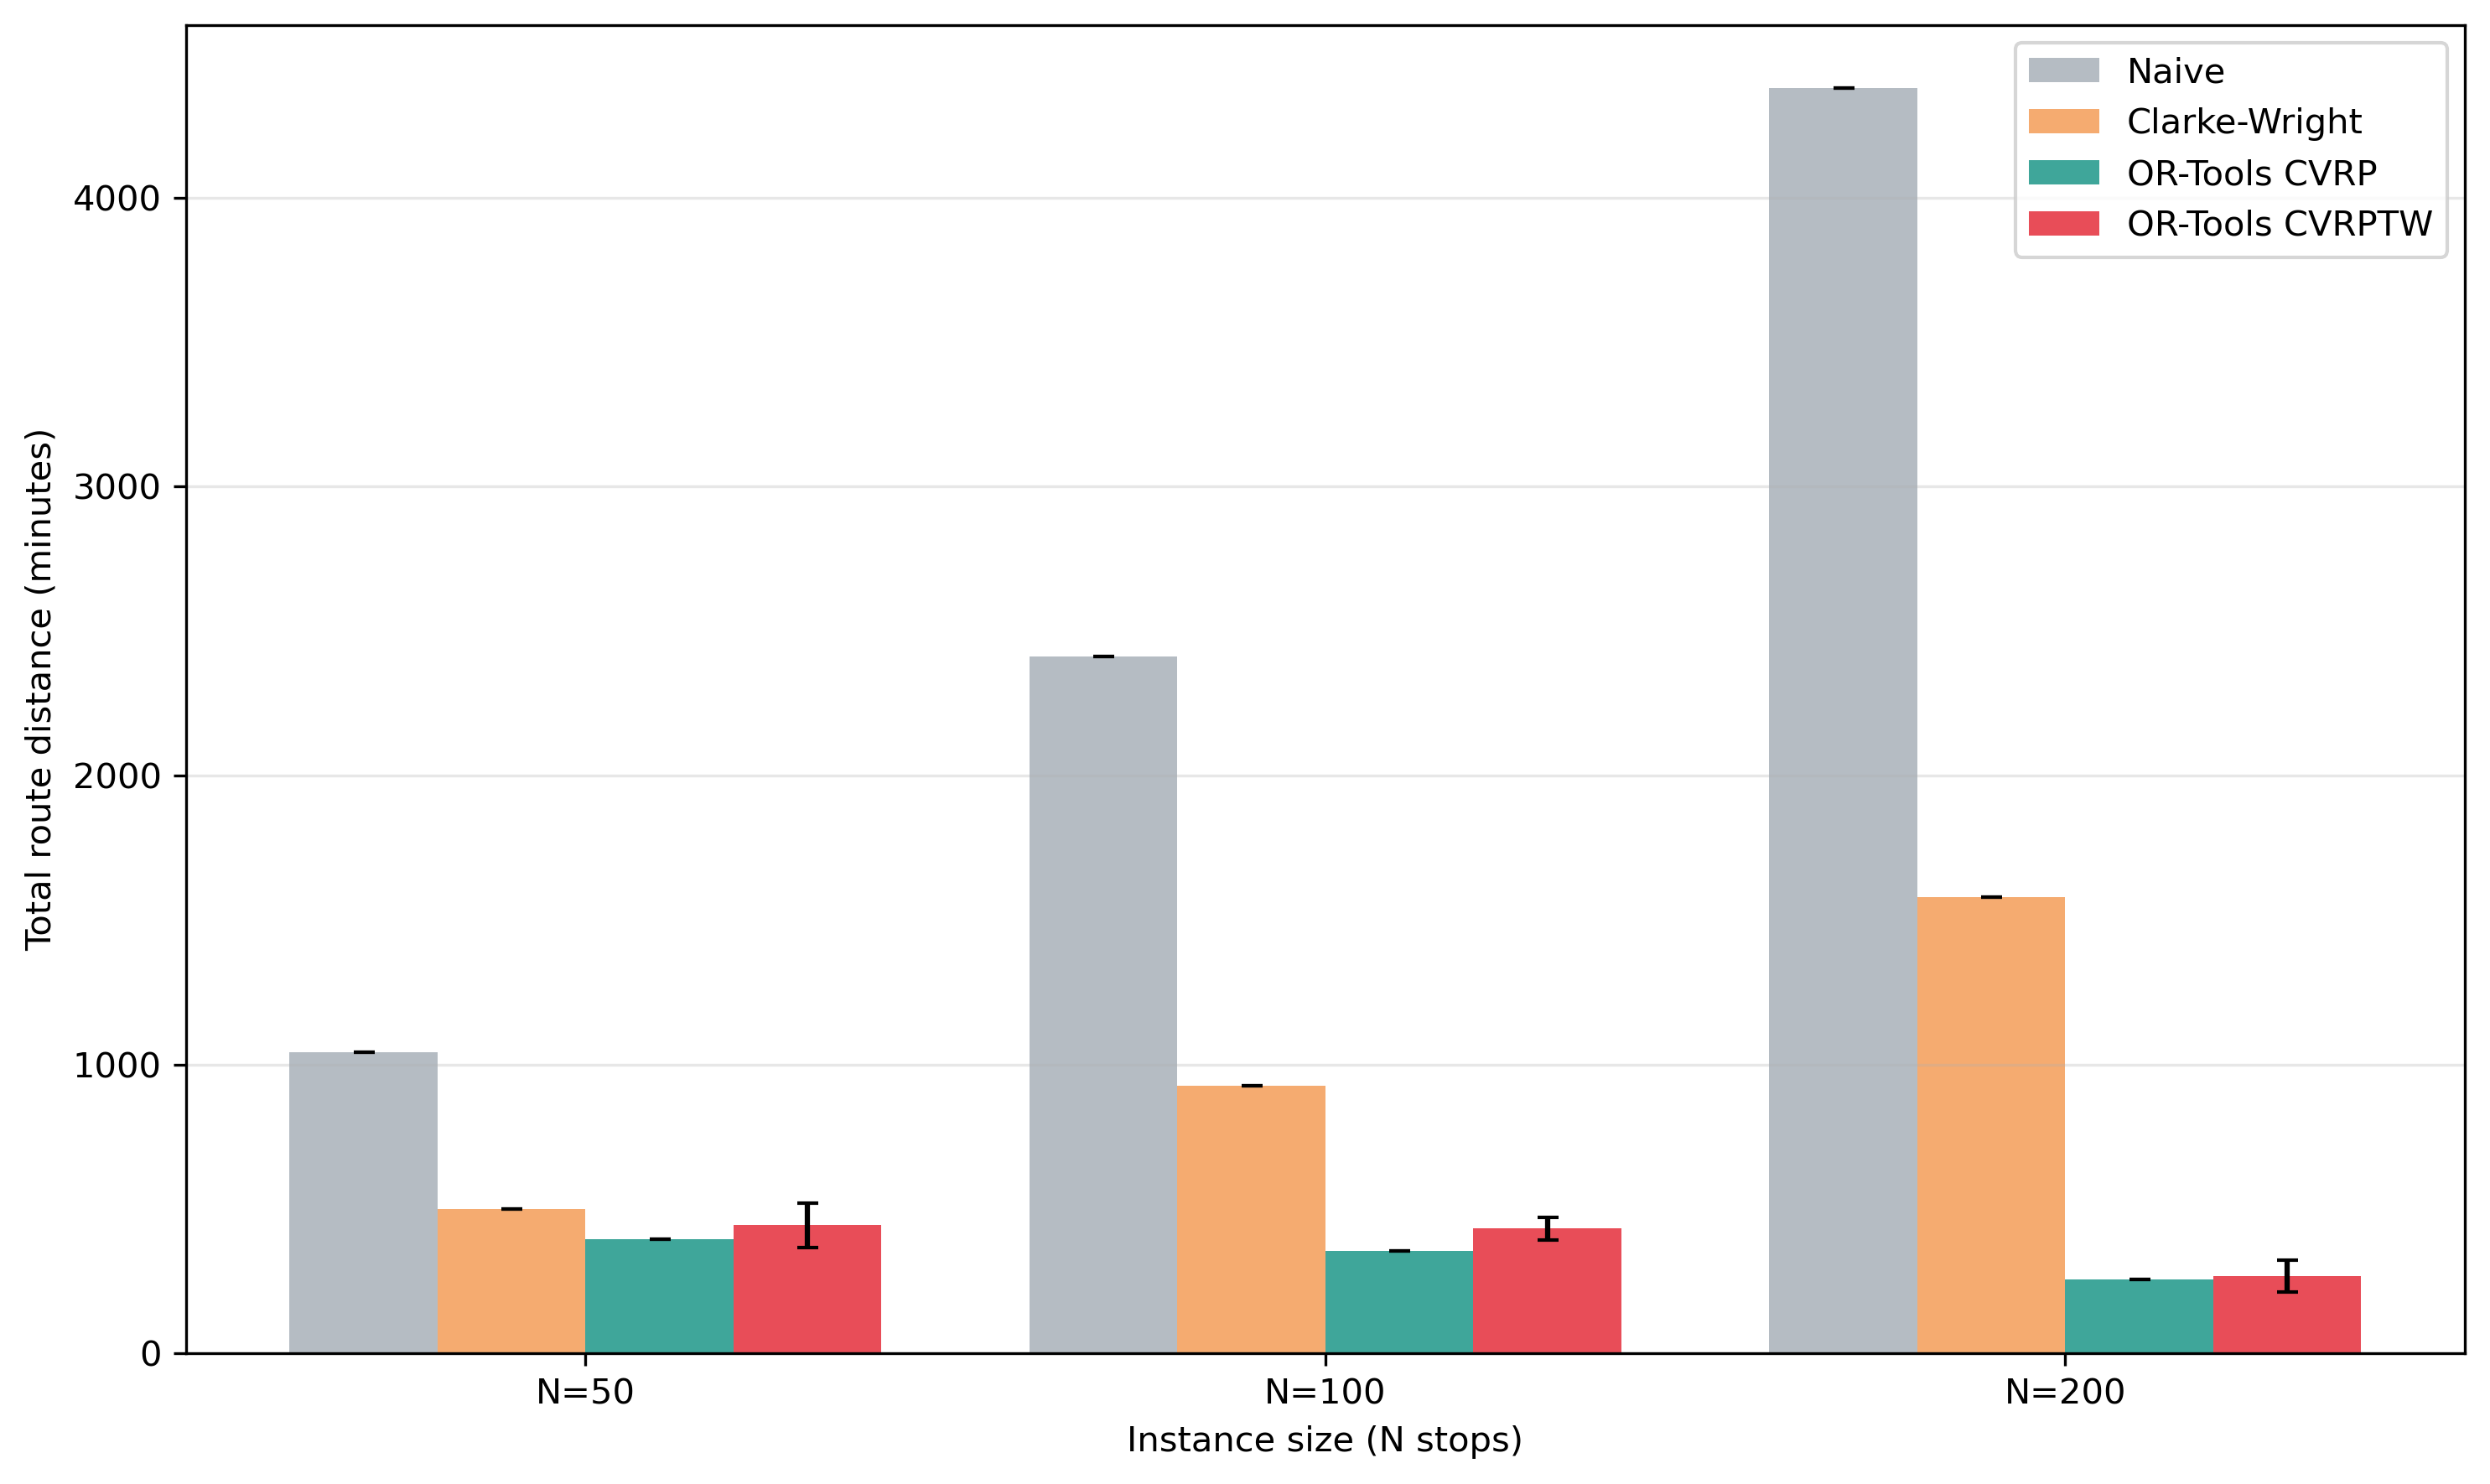

Saved benchmark_distance.png / .pdf


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ns = [50, 100, 200]
x  = np.arange(len(ns))
width = 0.2
colors = {'naive':'#adb5bd','clarke-wright':'#f4a261','ortools-cvrp':'#2a9d8f','ortools-cvrptw':'#e63946'}
labels = {'naive':'Naive','clarke-wright':'Clarke-Wright','ortools-cvrp':'OR-Tools CVRP','ortools-cvrptw':'OR-Tools CVRPTW'}

for i, algo in enumerate(algo_order):
    if algo not in pivot_dist.index: continue
    means = [pivot_dist.loc[algo, N] if N in pivot_dist.columns else 0 for N in ns]
    stds  = [pivot_std.loc[algo,  N] if N in pivot_std.columns  else 0 for N in ns]
    stds  = [0 if pd.isna(s) else s for s in stds]
    ax.bar(x + i*width, means, width, label=labels[algo],
           color=colors[algo], yerr=stds, capsize=3, alpha=0.9)

ax.set_xlabel('Instance size (N stops)')
ax.set_ylabel('Total route distance (minutes)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'N={n}' for n in ns])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/benchmark_distance.png', dpi=300, bbox_inches='tight')
plt.savefig('results/benchmark_distance.pdf', bbox_inches='tight')
plt.show()
print('Saved benchmark_distance.png / .pdf')

## Cell 7 — Figure 2: solve time line chart

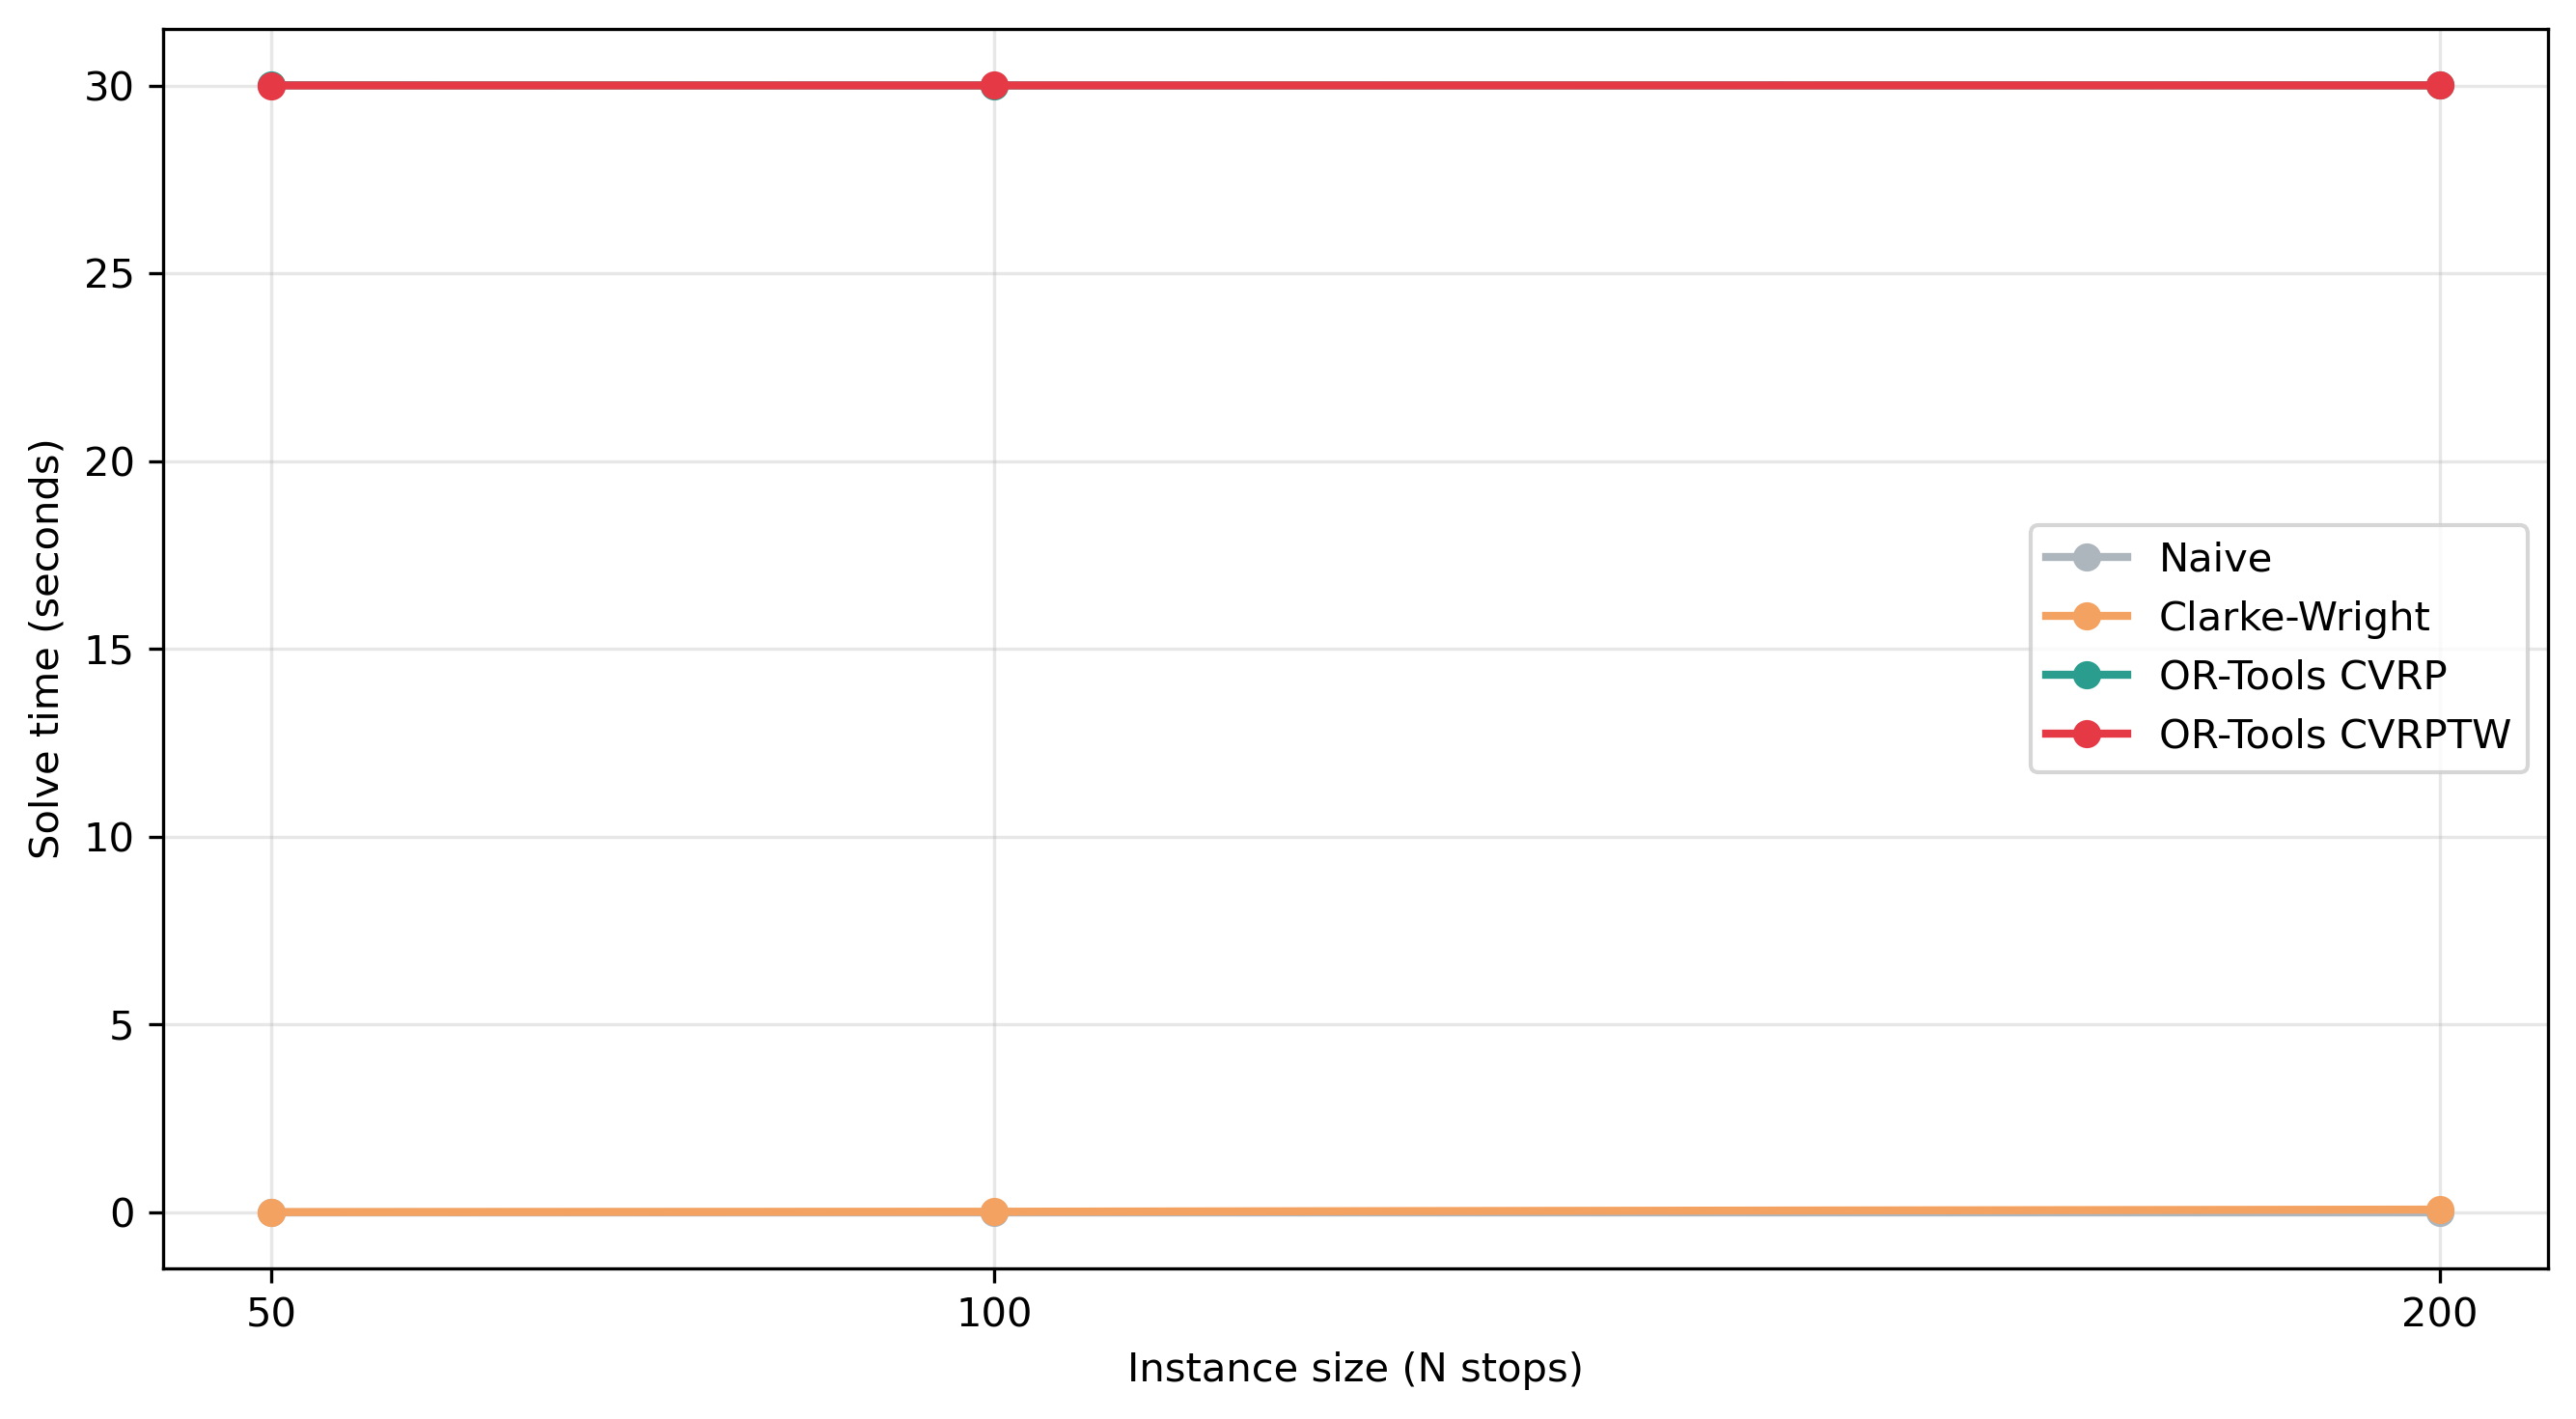

Saved benchmark_time.png / .pdf


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for algo in algo_order:
    if algo not in pivot_time.index: continue
    means = [pivot_time.loc[algo, N] if N in pivot_time.columns else np.nan for N in ns]
    ax.plot(ns, means, 'o-', label=labels[algo], color=colors[algo], linewidth=2, markersize=6)

ax.set_xlabel('Instance size (N stops)')
ax.set_ylabel('Solve time (seconds)')
ax.set_xticks(ns)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/benchmark_time.png', dpi=300, bbox_inches='tight')
plt.savefig('results/benchmark_time.pdf', bbox_inches='tight')
plt.show()
print('Saved benchmark_time.png / .pdf')

## Cell 8 — Edge cost model ablation at N=100

In [8]:
from src.graph import enrich_graph
import copy

inst100   = instances[100]
all_nodes = [depot_node] + inst100['customers']

ablation_configs = {
    'distance-only':    {'QUALITY_PENALTY_UNPAVED': 1.0, 'QUALITY_PENALTY_PAVED': 1.0,
                         'SPEED_BY_HIGHWAY': {k: 1.0 for k in ['motorway','trunk','primary',
                         'secondary','tertiary','residential','service','unclassified','track','path','default']}},
    'speed-class-only': {'QUALITY_PENALTY_UNPAVED': 1.0, 'QUALITY_PENALTY_PAVED': 1.0},
    'full-composite':   None,   # default params
}

ablation_results = []
for config_name, params in ablation_configs.items():
    print(f'Building matrix for {config_name}...', end=' ', flush=True)
    G_abl = copy.deepcopy(G)
    enrich_graph(G_abl, params=params)
    mat_abl = build_distance_matrix(G_abl, all_nodes, weight='composite_weight')
    max_f = mat_abl[mat_abl != np.inf].max()
    mat_abl = np.where(mat_abl == np.inf, max_f * 10, mat_abl)

    sol = solve_cvrp(G_abl, depot_node, inst100['customers'], inst100['demands'],
                      CAPACITY_KG, N_VEHICLES, SOLVE_LIMIT, dist_matrix=mat_abl)
    ablation_results.append({'config': config_name, 'total_dist': sol.total_distance_km,
                               'n_routes': sol.num_routes})
    print(f'{sol.total_distance_km:.2f} min')

df_abl = pd.DataFrame(ablation_results)
baseline = df_abl[df_abl['config']=='distance-only']['total_dist'].values[0]
df_abl['vs_distance_only_pct'] = (df_abl['total_dist'] - baseline) / baseline * 100
print('\nEdge cost model ablation (N=100, OR-Tools CVRP):')
print(df_abl.to_string(index=False))

Building matrix for distance-only... 12388.81 min
Building matrix for speed-class-only... 353.52 min
Building matrix for full-composite... 353.52 min

Edge cost model ablation (N=100, OR-Tools CVRP):
          config   total_dist  n_routes  vs_distance_only_pct
   distance-only 12388.808036         5              0.000000
speed-class-only   353.519683         5            -97.146459
  full-composite   353.519683         5            -97.146459


## Cell 9 — Write full benchmark CSV and validate

In [9]:
# Save raw results
csv_path = 'results/cvrp_benchmark_full.csv'
df_raw.to_csv(csv_path, index=False)
print(f'Saved {len(df_raw)} rows to {csv_path}')

# Save ablation
df_abl.to_csv('results/cvrp_ablation.csv', index=False)

# Validation
assert os.path.exists(csv_path)
assert os.path.exists('results/benchmark_distance.png')
assert os.path.exists('results/benchmark_time.png')

df_check = pd.read_csv(csv_path)
expected_rows = len([50,100,200]) * N_REPS * 4   # 4 algorithms
assert len(df_check) == expected_rows, f'Expected {expected_rows} rows, got {len(df_check)}'

# OR-Tools must beat naive on every instance size
for N in [50, 100, 200]:
    naive_mean = df_check[(df_check['n']==N)&(df_check['algorithm']=='naive')]['total_dist'].mean()
    cvrp_mean  = df_check[(df_check['n']==N)&(df_check['algorithm']=='ortools-cvrp')]['total_dist'].mean()
    assert cvrp_mean < naive_mean, f'OR-Tools must beat naive at N={N}'
    improvement = (naive_mean - cvrp_mean) / naive_mean * 100
    print(f'N={N:>3}: OR-Tools improvement over naive = {improvement:.1f}%')

print('\n✓ Phase 11 validation passed. Proceed to notebook 07.')

Saved 36 rows to results/cvrp_benchmark_full.csv
N= 50: OR-Tools improvement over naive = 62.2%
N=100: OR-Tools improvement over naive = 85.3%
N=200: OR-Tools improvement over naive = 94.1%

✓ Phase 11 validation passed. Proceed to notebook 07.
